# Mixture lab — observational dependence between clients

The drift sweep is an excitation experiment: each world moves **one** district and holds
everything else fixed, so stacking a network's worlds gives a design matrix with one active
column per world. This notebook turns that into two things.

1. **Per sensor** — what fraction of which district's demand change it is reading.
2. **Per district pair** — how much district *j*'s observations are contaminated by district
   *k*'s demand. That is `R[j,k]`: *a drift in k moves j's meters R times as much as an
   equivalent drift in j does*.

**Naming, because the over-claim is easy.** Each district's demand is generated independently
in the simulator. Nothing here says client *j*'s **demand** depends on client *k*'s. It says
*j*'s **observations** are contaminated by *k*'s demand — which is exactly the confound
federated training faces, and the reason a measured version of it is worth having.

**What changed in this version.** The earlier share-based matrix normalised each sensor's
responses to a simplex and gated them at `null_factor × ||Δz||`. That answered "of what this
gauge saw, what fraction came from k" — a composition, not a dependence — and the hard gate
made rows one-hot as soon as one district cleared, which is why KY7 and D-Town returned
`diag 1.000 / offdiag 0.000` while Graeme at a lower threshold returned `0.69 / 0.077`. §6
replaces it with a projection-based, soft-thresholded elasticity. The shares are kept as a
per-sensor read-out only.

## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 80, "display.max_rows", 250)

HERE = pathlib.Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
for p in (HERE, ROOT / "src", ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import landuse_world as lw, signal_probe as sp, landuse_sweep as ls, mixture_probe as mp

SWEEP = ROOT / "data" / "09_experiments" / "landuse_sweep"
OUT = ROOT / "data" / "09_experiments" / "mixture"
OUT.mkdir(parents=True, exist_ok=True)
print(SWEEP, SWEEP.exists())

c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\landuse_sweep True


## 1. Worlds

In [2]:
CFG = ls.SweepCfg(
    networks=("ky7", "dtown", "graeme"),
    betas=(0.0, 0.15, 0.25, 0.35, 0.40, 0.50),
    districts=None, to_land_use="industrial", to_income="low",
    n_months=44, days_per_month=14, warmup_months=2,
    max_neighbors_per_month=8, growth_chance=1.0,
    drift_ramp_days=7, seasonality_scale=0.0)

NETWORK, BETA = "graeme", 0.35
NULL_FACTOR, CORE_PURITY = 1.5, 0.85      # tiering only; §6 uses no threshold

PROBES = mp.load_cells(NETWORK, BETA, CFG, ROOT, SWEEP)
print(f"{NETWORK} @ beta={BETA}: {len(PROBES)} worlds ->", sorted(PROBES))

graeme @ beta=0.35: 5 worlds -> ['District_A', 'District_B', 'District_C', 'District_D', 'District_E']


## 2. Settling

`final` cannot start at `last_switch + ramp`: the profile is still moving there. The
threshold is self-calibrating — the reproducibility ceiling is measured from the reference
months and "settled" means within a slack of it, where the slack is at least twice the spread
of those months.

,drift_district,n_months,last_switch,settle_month,settled_from,settled_months,ok,need_n_months
0,District_A,44,6,6,7,37,True,10
1,District_B,44,9,8,9,35,True,12
2,District_C,44,9,8,9,35,True,12
3,District_D,44,10,9,10,34,True,13
4,District_E,44,9,8,9,35,True,12


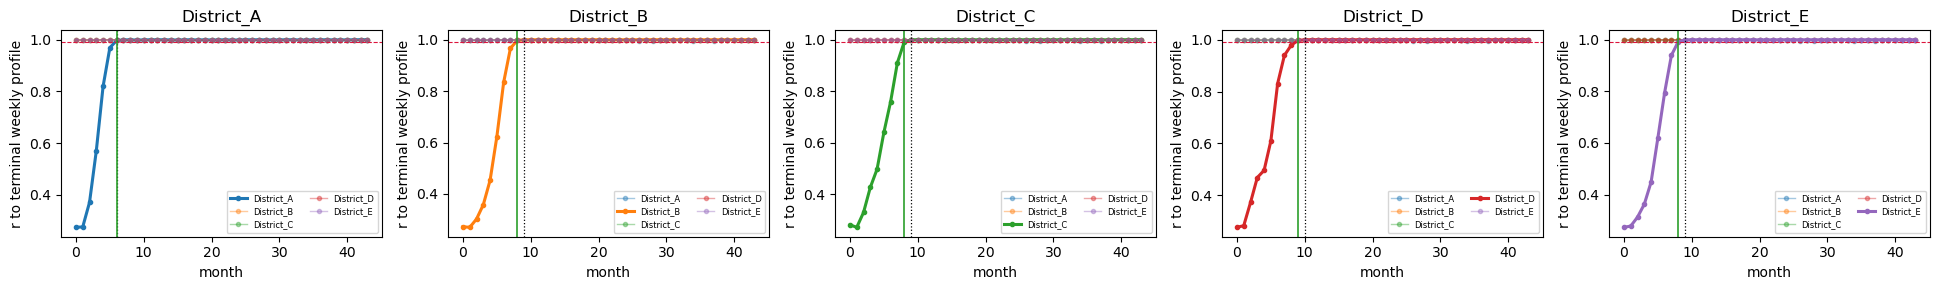

In [3]:
H = mp.horizon_check(PROBES)
display(H)
if not H["ok"].all():
    print(">>> rerun the sweep with a longer n_months before going further.")

tgts = sorted(PROBES)
fig, axes = plt.subplots(1, len(tgts), figsize=(3.9 * len(tgts), 3.0), squeeze=False)
for ax, d in zip(axes[0], tgts):
    mp.plot_settle(PROBES[d], ax=ax); ax.set_title(d)
plt.tight_layout(); plt.show()

## 3. Noise floor, and where it comes from

The split-half null is the shape wobble the world produces with nothing drifting. Its level
differs by almost 20x between networks, and that difference has driven every threshold
artefact so far — so it is worth explaining rather than absorbing.

The regression asks whether a gauge's own noise floor grows with proximity to storage:
`log10(null) ~ hops_to_storage + elevation`. Hops are unweighted shortest-path steps on the
pipe graph to the nearest tank or reservoir. Crude, but it needs no calibration. A
**negative** `b_hops` means noise falls with distance from storage, i.e. storage is the
source. A flat fit does not clear storage — it says only that this predictor does not
carry it.

In [4]:
P0 = PROBES[tgts[0]]
cand = sp.candidates(P0)
lo0, hi0 = mp.baseline_window(P0); lo1, hi1 = mp.settled_window(P0)
raw = mp.split_half_null(P0, cand)
matched = mp.split_half_null(P0, cand, windows=((lo0, hi0), (lo1, hi1)))
print(f"baseline months {lo0//P0.steps_month}..{hi0//P0.steps_month-1} | "
      f"settled months {lo1//P0.steps_month}..{hi1//P0.steps_month-1}")
print(f"null raw median {np.median(raw):.3f} | matched median {np.median(matched):.3f}")

baseline months 0..1 | settled months 7..43
null raw median 0.529 | matched median 0.271


  District_A: settled from month 7
  District_B: settled from month 9
  District_C: settled from month 9
  District_D: settled from month 10
  District_E: settled from month 9


,kind,n,r2,intercept,b_hops,b_elevation,r_hops_only,null_median,hops_median
0,pressure,112,0.239,-0.0132,-0.0023,-0.0858,-0.4888,0.2579,7.0


,kind,n,r2,intercept,b_hops,b_log10_mean_flow,r_hops_only,null_median,hops_median
0,flow,164,0.7583,0.3764,-0.0082,-0.6509,0.4082,0.4739,7.0


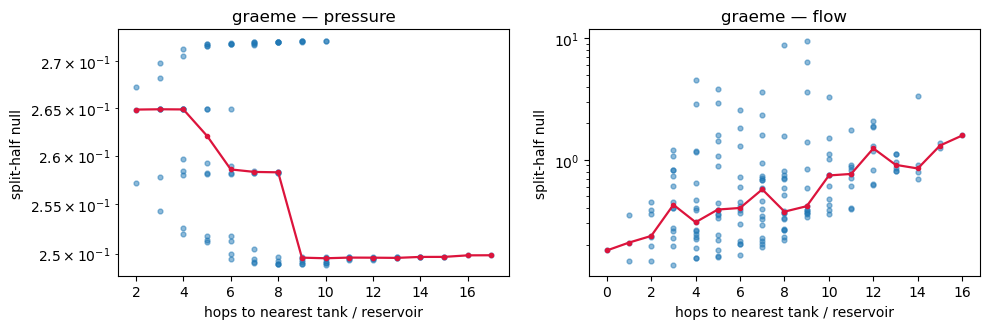

In [5]:
RES = mp.build_mixture(PROBES, null_factor=NULL_FACTOR, core_purity=CORE_PURITY)

NS = {k: mp.null_vs_storage(P0, RES, kind=k) for k in ("pressure", "flow")}
for k, r in NS.items():
    display(r["fit"] if r["fit"] is not None else r["note"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, k in zip(axes, ("pressure", "flow")):
    mp.plot_null_vs_storage(NS[k], ax=ax, label=f"{NETWORK} — {k}")
plt.tight_layout(); plt.show()

## 4. Per-sensor mixture

`n_live<=1_%` is the number to read first. If nearly every gauge cleared the gate for exactly
one district, the shares are one-hot by construction and say nothing about coupling — which
is a statement about the threshold, not the network. §6 avoids the gate entirely; these tiers
exist only to label gauges for placement.

In [6]:
display(mp.mixture_diagnostics(RES))
display(mp.tier_sensitivity(RES, factors=(0.5, 1.0, 1.5, 2.0, 3.0, 5.0)))
display(mp.purity_histogram(RES))

,kind,n,unusable_%,n_live<=1_%,n_live_mean,purity_median,snr_median,neg_mass_%
0,flow,164,0.61,23.171,2.878,0.770,18.677,41.463
1,pressure,112,0.00,0.000,5.000,0.312,15.710,0.000


,null_factor,core_purity,kind,core,transition,foreign,unusable,n_live_mean
0,0.5,0.85,flow,71,71,22,0,4.82
1,0.5,0.85,pressure,0,83,29,0,5.00
2,1.0,0.85,flow,71,71,22,0,3.67
3,1.0,0.85,pressure,0,83,29,0,5.00
4,1.5,0.85,flow,71,70,22,1,2.88
5,1.5,0.85,pressure,0,83,29,0,5.00
6,2.0,0.85,flow,71,70,22,1,2.34
7,2.0,0.85,pressure,0,83,29,0,5.00
8,3.0,0.85,flow,71,66,22,5,2.04
9,3.0,0.85,pressure,0,83,29,0,4.00


,kind,bin,n,share
0,flow,"[0.0, 0.15)",22,0.135
1,flow,"[0.15, 0.3)",23,0.141
2,flow,"[0.3, 0.5)",21,0.129
3,flow,"[0.5, 0.7)",10,0.061
4,flow,"[0.7, 0.85)",16,0.098
5,flow,"[0.85, 0.95)",8,0.049
6,flow,"[0.95, 1.001)",63,0.387
7,pressure,"[0.0, 0.15)",29,0.259
8,pressure,"[0.15, 0.3)",24,0.214
9,pressure,"[0.3, 0.5)",59,0.527


kind flow                             pressure           
tier core foreign transition unusable  foreign transition
n      71      22         70        1       29         83

,district,kind,n,core,transition,foreign,unusable,readable_band,purity_max,purity_median,top_second
0,District_A,flow,17,16,0,1,0,0,1.000,1.000,
1,District_B,flow,44,30,12,1,1,9,1.000,1.000,
2,District_C,flow,24,0,12,12,0,0,0.396,0.137,District_E
3,District_D,flow,30,1,22,7,0,6,1.000,0.286,District_E
4,District_E,flow,49,24,24,1,0,19,1.000,0.838,District_D


,district,kind,n,core,transition,foreign,unusable,readable_band,purity_max,purity_median,top_second
0,District_A,pressure,11,0,0,11,0,0,0.043,0.043,District_B
1,District_B,pressure,29,0,29,0,0,29,0.437,0.436,District_E
2,District_C,pressure,18,0,0,18,0,0,0.093,0.093,District_B
3,District_D,pressure,24,0,24,0,0,0,0.229,0.228,District_B
4,District_E,pressure,30,0,30,0,0,0,0.314,0.313,District_B


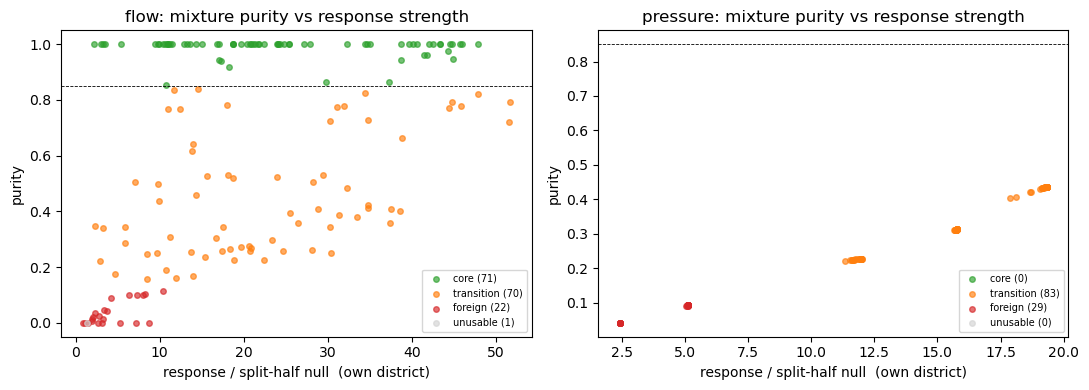

In [7]:
MIX = RES["mixture"]
display(MIX.groupby(["kind", "tier"]).size().rename("n").to_frame().T)
display(mp.zones(RES, "flow"))
display(mp.zones(RES, "pressure"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for ax, kind in zip(axes, ("flow", "pressure")):
    mp.plot_purity(RES, kind, ax=ax)
plt.tight_layout(); plt.show()

,id,home,kind,role,tier,purity,second,w_second,snr_home,n_live,neg_mass
197,q_181,District_E,flow,internal,transition,0.793,District_D,0.207,51.711,2,-0.000
251,q_67,District_E,flow,boundary,transition,0.721,District_D,0.279,51.497,3,0.010
259,q_78,District_E,flow,internal,transition,0.821,District_D,0.179,47.899,2,-0.000
145,q_134,District_B,flow,internal,transition,0.664,District_E,0.150,38.861,4,-0.000
274,q_97,District_D,flow,boundary,transition,0.400,District_E,0.498,38.564,5,0.002
226,q_43,District_D,flow,internal,transition,0.409,District_E,0.553,37.471,5,0.001
273,q_96,District_D,flow,internal,transition,0.360,District_E,0.531,37.437,5,0.001
256,q_73,District_D,flow,internal,transition,0.411,District_E,0.589,34.806,5,0.057
271,q_94,District_D,flow,boundary,transition,0.422,District_E,0.578,34.749,5,0.074
231,q_48,District_D,flow,internal,transition,0.728,District_E,0.272,34.747,3,0.020


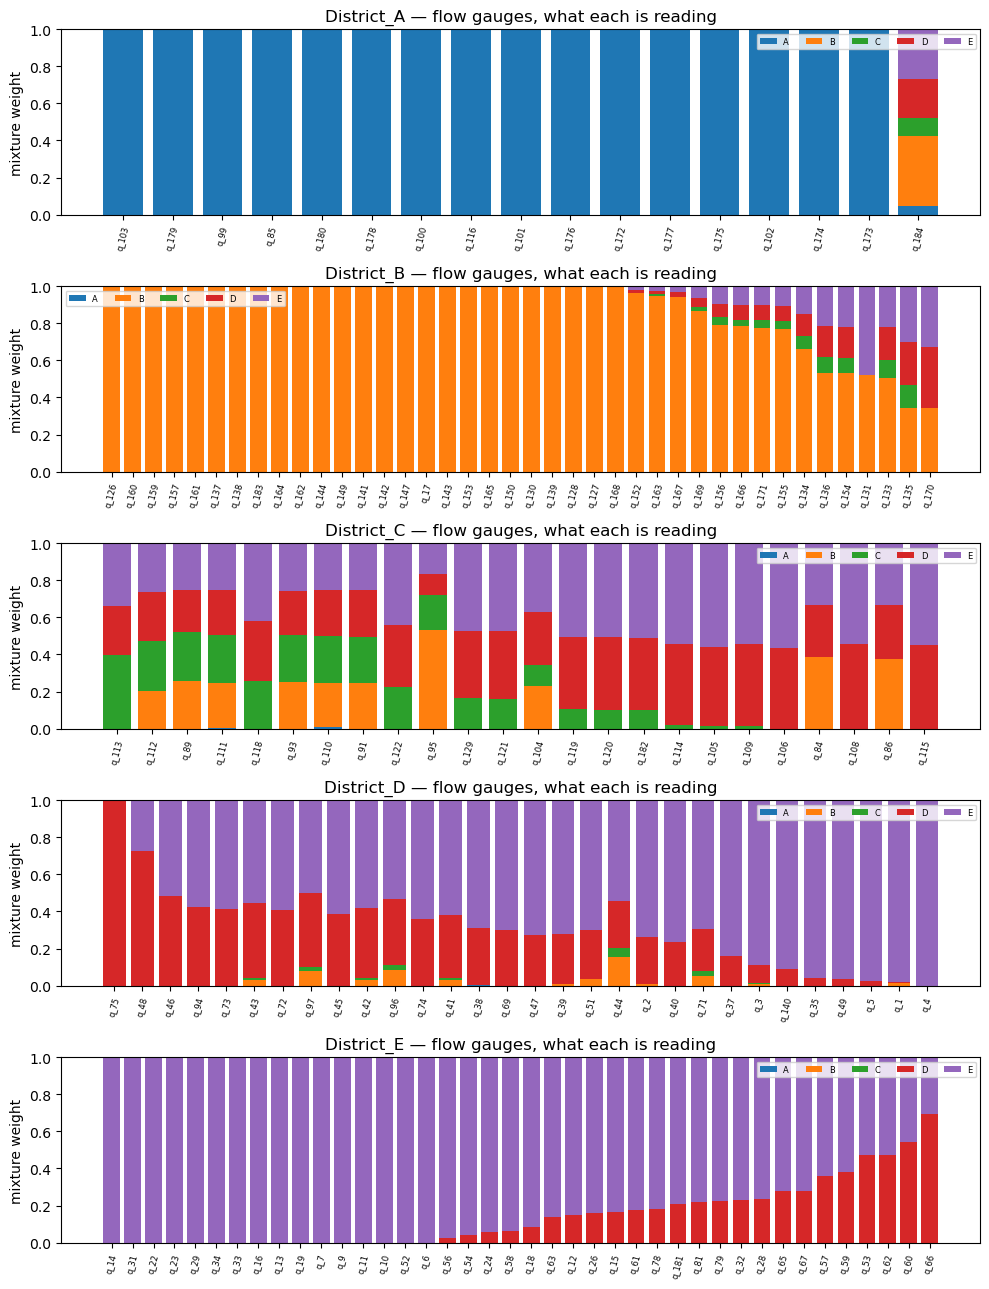

In [8]:
# The readable set: gauges carrying a quantified blend rather than a one-hot.
cols = ["id", "home", "kind", "role", "tier", "purity", "second", "w_second",
        "snr_home", "n_live", "neg_mass"]
display(MIX[(MIX["tier"] == "transition") & (MIX["w_second"] > 0.15)]
        .sort_values("snr_home", ascending=False).head(20)[cols].round(3))

fig, axes = plt.subplots(len(tgts), 1, figsize=(10, 2.6 * len(tgts)))
for ax, d in zip(np.atleast_1d(axes), tgts):
    mp.plot_mixture_bars(RES, d, "flow", top=40, ax=ax)
plt.tight_layout(); plt.show()

## 5. Dependence — the corrected estimator

Per sensor `s`, in the world where district `k` drifted:

```
u_k    = Δz_d(k) / ||Δz_d(k)||            unit direction of k's demand-shape change
P[s,k] = <Δz_s , u_k>                     the response along it
ν[s,k] = |<split-half Δz_s , u_k>|        the noise ON THE SAME DIRECTION
P̃      = sign(P)·max(|P| − ν, 0)          soft threshold — continuous, no cliff
E[s,k] = P̃[s,k] / ||Δz_d(k)||             per unit of excitation
```

`D[j,k]` is the mean `|E|` over **every** gauge homed in `j` — not the best few. Taking the
top gauges by own-district SNR selects the purest ones and drives the off-diagonal to zero by
construction, which is the circularity that made the earlier matrices look like identity.

`R = D / diag(D)` is the form to quote: diagonal 1, and the same gauges appear in numerator
and denominator so the placement confound largely cancels. `R[j,k] > 1` is meaningful and not
an error — it says j's meters respond *more* to k's drift than to j's own.

gauges per district — flow: {'District_A': 17, 'District_B': 44, 'District_C': 24, 'District_D': 30, 'District_E': 49}


,District_A,District_B,District_C,District_D,District_E
District_A,0.9359,0.0162,0.0056,0.0102,0.0123
District_B,0.0052,0.8764,0.0411,0.0991,0.1333
District_C,0.0034,0.5140,0.4172,0.6941,0.7994
District_D,0.0003,0.0230,0.0068,0.2643,0.6062
District_E,0.0004,0.0039,0.0011,0.2955,0.8380


,District_A,District_B,District_C,District_D,District_E
District_A,1.000,0.017,0.006,0.011,0.013
District_B,0.006,1.000,0.047,0.113,0.152
District_C,0.008,1.232,1.000,1.664,1.916
District_D,0.001,0.087,0.026,1.000,2.293
District_E,0.000,0.005,0.001,0.353,1.000


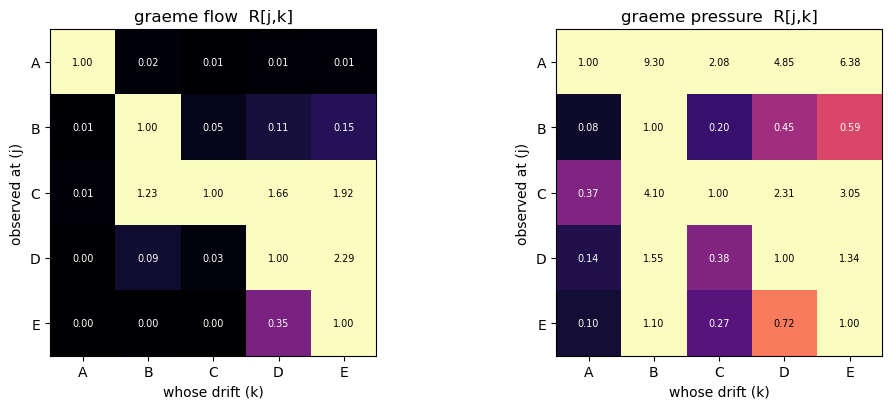

In [9]:
D_flow, R_flow, n_flow = mp.dependence(RES, kind="flow")
D_pres, R_pres, n_pres = mp.dependence(RES, kind="pressure")
print("gauges per district — flow:", n_flow.to_dict())
display(D_flow.round(4))
display(R_flow.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
mp.plot_matrix(R_flow, ax=axes[0], title=f"{NETWORK} flow  R[j,k]", vmax=1.0,
               xlabel="whose drift (k)", ylabel="observed at (j)")
mp.plot_matrix(R_pres, ax=axes[1], title=f"{NETWORK} pressure  R[j,k]", vmax=1.0,
               xlabel="whose drift (k)", ylabel="observed at (j)")
plt.tight_layout(); plt.show()

In [10]:
display(mp.dependence_summary(R_flow))
display(mp.asymmetry(R_flow))

,in_mean,in_max,out_mean,out_max,net,strongest_source
District_A,0.012,0.017,0.004,0.008,-0.008,District_B
District_B,0.080,0.152,0.335,1.232,0.256,District_E
District_C,1.205,1.916,0.020,0.047,-1.185,District_E
District_D,0.602,2.293,0.535,1.664,-0.067,District_E
District_E,0.090,0.353,1.094,2.293,1.004,District_D


,District_A,District_B,District_C,District_D,District_E
District_A,0.000,0.011,-0.002,0.010,0.013
District_B,-0.011,0.000,-1.185,0.026,0.147
District_C,0.002,1.185,0.000,1.638,1.915
District_D,-0.010,-0.026,-1.638,0.000,1.941
District_E,-0.013,-0.147,-1.915,-1.941,0.000


`in_mean` is how contaminated *j*'s meters are; `out_mean` is how far *j*'s own drift travels.
High `out` with low `in` is an upstream driver, the reverse a downstream sink. `net` is the
closest thing to a direction this design supports — it is an influence asymmetry, not a
causal one.

### Does the estimator behave as derived?

`noise_pass_rate` — share of (gauge, district) cells below their own noise floor. Near 0 means
the floor is underestimated and everything looks significant. `shrink_effect_r` — correlation
between raw and shrunk elasticities; near 1 means the result does not hinge on the soft
threshold. `diag_dominance` — share of gauges whose largest `|E|` is their own district; the
honest version of "hit rate", using no threshold and no tiering.

In [11]:
display(pd.concat([mp.estimator_checks(RES, "flow"),
                   mp.estimator_checks(RES, "pressure")], ignore_index=True))

# Sensitivity of the conclusion to the one remaining choice.
rows = []
for shrink in (True, False):
    for stat in ("mean", "median"):
        D_, R_, _ = mp.dependence(RES, "flow", shrink=shrink, stat=stat)
        A = R_.to_numpy().copy(); np.fill_diagonal(A, np.nan)
        rows.append({"shrink": shrink, "stat": stat,
                     "offdiag_mean": float(np.nanmean(A)),
                     "offdiag_max": float(np.nanmax(A))})
display(pd.DataFrame(rows).round(3))

,kind,n_gauges,noise_pass_rate,shrink_effect_r,diag_dominance,median_nu_over_proj
0,flow,164,0.2122,0.9994,0.6524,0.1121
1,pressure,112,0.0000,1.0000,0.2589,0.0033


,shrink,stat,offdiag_mean,offdiag_max
0,True,mean,0.398,2.293
1,True,median,0.534,3.822
2,False,mean,0.401,2.279
3,False,median,0.534,3.757


## 6. Response matrices

Rows are the district that **drifted**, columns where it was measured — the sweep's
`leak_matrix` layout, so the two read together. Each row is divided by its own diagonal, so an
entry is "this drift showed up at j's meters x as strongly as at its own".

The `core` / `transition` split is the point of the second and third panels: cores should be
close to diagonal by definition, and if the transition gauges are *not* far more coupled then
the tiering is not separating anything.

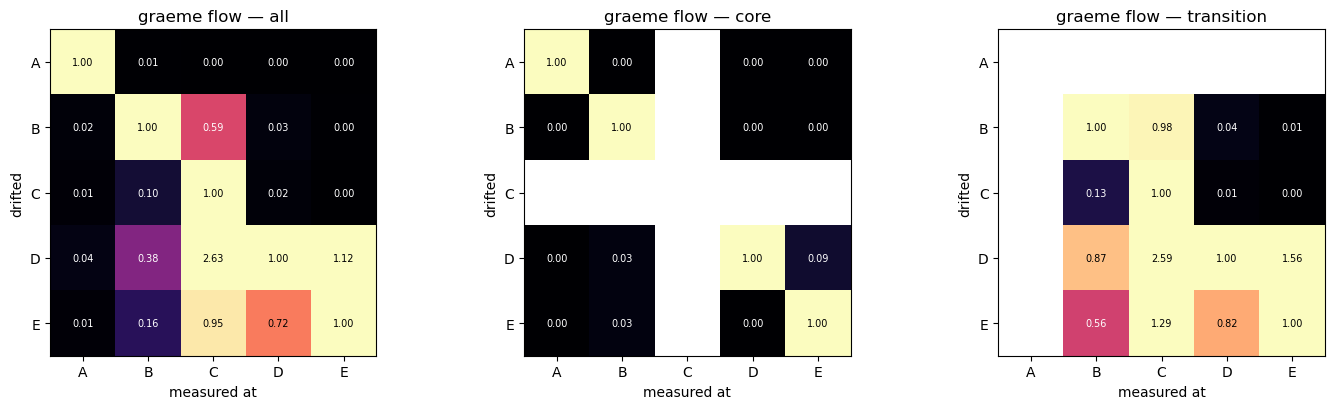

all         diagonal 1.000 | off-diagonal 0.339 | ratio 2.9x
core        diagonal 1.000 | off-diagonal 0.013 | ratio 74.5x
transition  diagonal 1.000 | off-diagonal 0.739 | ratio 1.4x


In [12]:
def response_panels(base, kind="flow", top=None):
    out = {}
    mixf = base["mixture"]
    out["all"] = mp.response_matrix(base, kind, top=top)
    for tier in ("core", "transition"):
        if (mixf["tier"] == tier).any():
            out[tier] = mp.response_matrix(base, kind, top=top, tier=tier, mixture=mixf)
    return out

PAN = response_panels(RES, "flow")
fig, axes = plt.subplots(1, len(PAN), figsize=(4.8 * len(PAN), 4.2), squeeze=False)
for ax, (name, A) in zip(axes[0], PAN.items()):
    mp.plot_matrix(A, ax=ax, title=f"{NETWORK} flow — {name}", vmax=1.0,
                   xlabel="measured at", ylabel="drifted")
plt.tight_layout(); plt.show()

for name, A in PAN.items():
    V = A.to_numpy(); off = V[~np.eye(len(V), dtype=bool)]
    print(f"{name:11s} diagonal {np.nanmean(np.diag(V)):.3f} | "
          f"off-diagonal {np.nanmean(off):.3f} | "
          f"ratio {np.nanmean(np.diag(V))/max(np.nanmean(off), 1e-9):.1f}x")

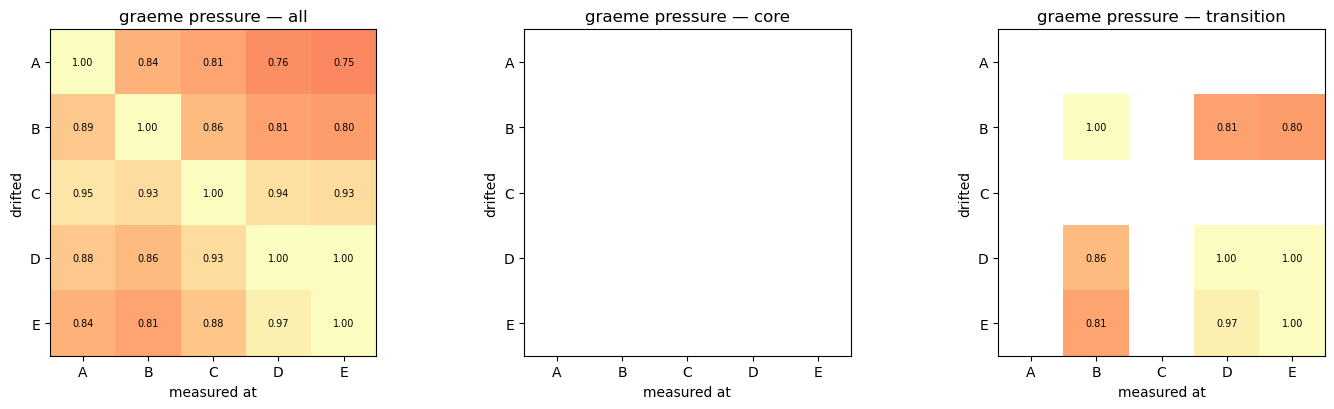

all         diagonal 1.000 | off-diagonal 0.871
core        diagonal nan | off-diagonal nan
transition  diagonal 1.000 | off-diagonal 0.874


C:\Users\arthu\AppData\Local\Temp\ipykernel_6904\4217235095.py:10: RuntimeWarning: Mean of empty slice
  print(f"{name:11s} diagonal {np.nanmean(np.diag(V)):.3f} | "
C:\Users\arthu\AppData\Local\Temp\ipykernel_6904\4217235095.py:11: RuntimeWarning: Mean of empty slice
  f"off-diagonal {np.nanmean(off):.3f}")


In [13]:
PANP = response_panels(RES, "pressure")
if PANP:
    fig, axes = plt.subplots(1, len(PANP), figsize=(4.8 * len(PANP), 4.2), squeeze=False)
    for ax, (name, A) in zip(axes[0], PANP.items()):
        mp.plot_matrix(A, ax=ax, title=f"{NETWORK} pressure — {name}", vmax=1.0,
                       xlabel="measured at", ylabel="drifted")
    plt.tight_layout(); plt.show()
    for name, A in PANP.items():
        V = A.to_numpy(); off = V[~np.eye(len(V), dtype=bool)]
        print(f"{name:11s} diagonal {np.nanmean(np.diag(V)):.3f} | "
              f"off-diagonal {np.nanmean(off):.3f}")

## 7. Contiguity of the core sets

,district,kind,n_core,components,largest_share
0,District_A,flow,16,1,1.0
1,District_B,flow,30,1,1.0
2,District_C,flow,0,0,NaN
3,District_D,flow,1,1,1.0
4,District_E,flow,24,1,1.0
5,District_A,pressure,0,0,NaN
6,District_B,pressure,0,0,NaN
7,District_C,pressure,0,0,NaN
8,District_D,pressure,0,0,NaN
9,District_E,pressure,0,0,NaN


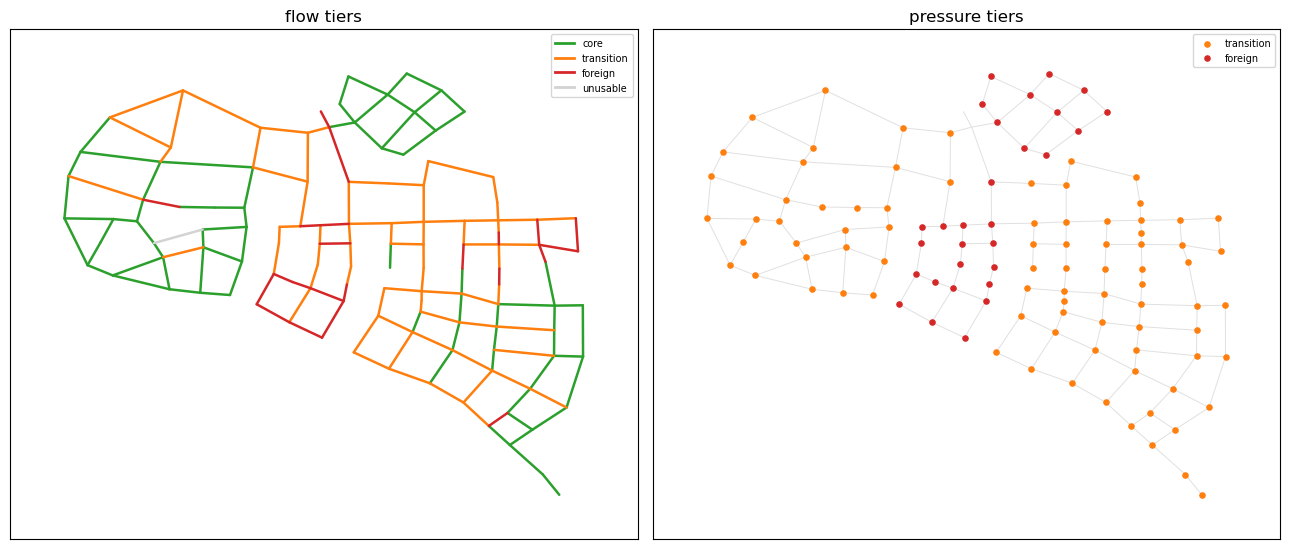

In [14]:
display(pd.concat([mp.core_connectivity(P0, RES, "flow"),
                   mp.core_connectivity(P0, RES, "pressure")], ignore_index=True))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
mp.plot_tier_map(P0, RES, "flow", ax=axes[0])
mp.plot_tier_map(P0, RES, "pressure", ax=axes[1])
plt.tight_layout(); plt.show()

## 8. Is the response operator linear?

`E` is already per unit of excitation, so if the network responds linearly it is
beta-invariant: `r ≈ 1` and `slope ≈ 1`. The slope's distance from 1 is the size of the
non-linearity, and it decides whether a dependence matrix measured at one operating point can
be quoted at another.

,kind,compare,n,r,slope,median_ratio
0,flow,beta=0.35 vs beta=0.0,652,0.820,0.740,0.507
1,pressure,beta=0.35 vs beta=0.0,560,1.000,0.422,0.423
2,flow,beta=0.35 vs beta=0.15,650,0.880,0.827,0.707
3,pressure,beta=0.35 vs beta=0.15,560,1.000,0.613,0.612
4,flow,beta=0.35 vs beta=0.25,649,0.918,0.885,0.857
5,pressure,beta=0.35 vs beta=0.25,560,1.000,0.785,0.783
6,flow,beta=0.35 vs beta=0.4,649,0.942,0.998,1.054
7,pressure,beta=0.35 vs beta=0.4,560,1.000,1.126,1.129
8,flow,beta=0.35 vs beta=0.5,664,0.848,0.999,1.123
9,pressure,beta=0.35 vs beta=0.5,560,1.000,1.418,1.437


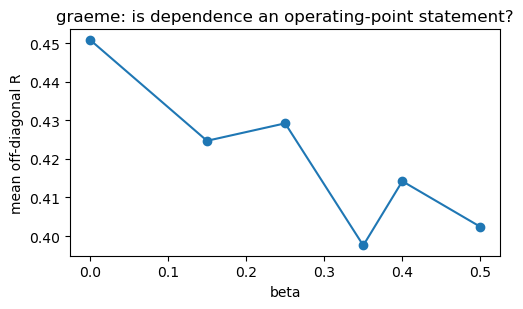

In [15]:
rows, mats = [], {}
for b in CFG.betas:
    if b == BETA:
        continue
    pr = mp.load_cells(NETWORK, b, CFG, ROOT, SWEEP)
    if len(pr) != len(PROBES):
        print(f"beta={b}: {len(pr)}/{len(PROBES)} worlds, skipped"); continue
    rb = mp.build_mixture(pr, null_factor=NULL_FACTOR, core_purity=CORE_PURITY,
                          verbose=False)
    for kind in ("flow", "pressure"):
        rows.append(mp.beta_linearity(RES, rb, kind, f"beta={BETA}", f"beta={b}"))
    mats[b] = mp.dependence(rb, "flow")[1]
LIN = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
display(LIN)

if mats:
    off = {b: float(np.nanmean(np.where(np.eye(len(M), dtype=bool), np.nan,
                                        M.to_numpy())))
           for b, M in {**mats, BETA: R_flow}.items()}
    s = pd.Series(off).sort_index()
    fig, ax = plt.subplots(figsize=(5.2, 3.2))
    ax.plot(s.index, s.to_numpy(), marker="o")
    ax.set(xlabel="beta", ylabel="mean off-diagonal R",
           title=f"{NETWORK}: is dependence an operating-point statement?")
    plt.tight_layout(); plt.show()

## 9. All networks

,network,kind,offdiag_mean,offdiag_max,diag_abs,null_median,diag_dominance
0,ky7,flow,0.073,0.342,0.671,5.330,0.778
1,ky7,pressure,1.559,4.954,0.119,5.330,0.002
2,dtown,flow,0.048,0.243,0.658,1.540,0.802
3,dtown,pressure,0.053,0.356,0.600,1.540,0.945
4,graeme,flow,0.398,2.293,0.666,0.272,0.652
5,graeme,pressure,1.967,9.300,0.138,0.272,0.259


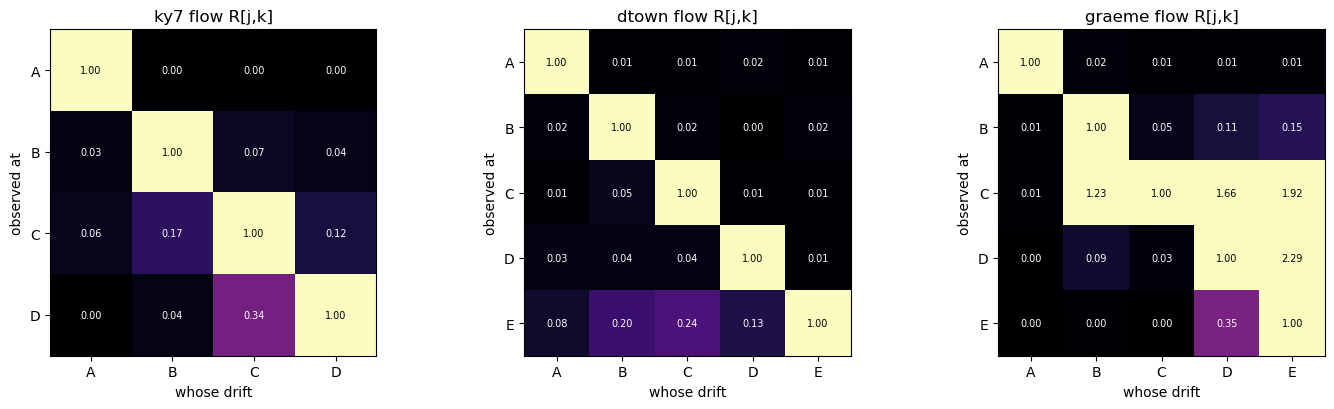

In [16]:
ALL, SUMM = {}, []
for net in CFG.networks:
    pr = mp.load_cells(net, BETA, CFG, ROOT, SWEEP)
    if len(pr) < 2:
        print(f"{net}: {len(pr)} worlds, skipped"); continue
    if not mp.horizon_check(pr)["ok"].all():
        print(f"{net}: horizon too short, skipped"); continue
    r = mp.build_mixture(pr, null_factor=NULL_FACTOR, core_purity=CORE_PURITY,
                         verbose=False)
    ALL[net] = r
    for kind in ("flow", "pressure"):
        D_, R_, _ = mp.dependence(r, kind)
        A = R_.to_numpy().copy(); np.fill_diagonal(A, np.nan)
        SUMM.append({"network": net, "kind": kind,
                     "offdiag_mean": float(np.nanmean(A)),
                     "offdiag_max": float(np.nanmax(A)),
                     "diag_abs": float(np.nanmean(np.diag(D_.to_numpy()))),
                     "null_median": float(r["null"].median()),
                     "diag_dominance": float(
                         mp.estimator_checks(r, kind)["diag_dominance"].iat[0])})
display(pd.DataFrame(SUMM).round(3))

fig, axes = plt.subplots(1, len(ALL), figsize=(4.8 * len(ALL), 4.2), squeeze=False)
for ax, (net, r) in zip(axes[0], ALL.items()):
    mp.plot_matrix(mp.dependence(r, "flow")[1], ax=ax, vmax=1.0,
                   title=f"{net} flow R[j,k]", xlabel="whose drift",
                   ylabel="observed at")
plt.tight_layout(); plt.show()

## 10. Persist

In [17]:
for net, r in ALL.items():
    d = OUT / f"{net}_beta{BETA}"; d.mkdir(parents=True, exist_ok=True)
    r["mixture"].to_parquet(d / "mixture.parquet", index=False)
    r["gains"].to_parquet(d / "gains.parquet", index=False)
    mp.elasticity(r).to_csv(d / "elasticity.csv")
    for kind in ("flow", "pressure"):
        D_, R_, _ = mp.dependence(r, kind)
        D_.to_csv(d / f"dependence_abs_{kind}.csv")
        R_.to_csv(d / f"dependence_rel_{kind}.csv")
        mp.response_matrix(r, kind, top=None).to_csv(d / f"response_{kind}.csv")
    mp.zones(r, "flow").to_csv(d / "zones_flow.csv", index=False)
    mp.mixture_diagnostics(r).to_csv(d / "diagnostics.csv", index=False)
    print(net, "->", d)
pd.DataFrame(SUMM).to_csv(OUT / f"summary_beta{BETA}.csv", index=False)

ky7 -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\mixture\ky7_beta0.35
dtown -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\mixture\dtown_beta0.35
graeme -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\mixture\graeme_beta0.35


## 11. Read-out

**The dependence claim.** `R[j,k]` from §5, per network, with `dependence_summary` for the
in/out asymmetry. State it as observational dependence: *j*'s meters are contaminated by *k*'s
demand by this factor relative to *j*'s own. Do not state it as demand-level dependence — the
demands are independent by construction.

**Validity.** Three numbers gate the claim. `noise_pass_rate` well above 0 (the floor is not
underestimated), `shrink_effect_r` near 1 (the soft threshold is not driving it), and the
shrink/stat sensitivity table showing `offdiag_mean` stable across all four variants. If any
of those fails, the matrix is an artefact of the estimator.

**Transferability.** §8. `slope ≈ 1` and a flat off-diagonal across beta means the matrix is a
property of the network and can be quoted once. Otherwise every number carries its operating
point.

**Placement.** §4's zones and §7's contiguity. Cores for attribution, transition gauges for
measuring coupling, `foreign` gauges excluded outright.

**Caution on generalising.** Three networks, one partition each, one land-use contrast
(residential → industrial). The next round changes the district assignment, which will change
every number here. What should survive is the *method* — the excitation design, the projection
estimator, the noise floor and the `R` normalisation — not the specific matrices.